In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
os.environ['TF_FORCE_GPU_ALLOW_GROWTH'] = 'true'

import tensorflow as tf
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("GPU memory growth enabled:", gpus)
    except RuntimeError as e:
        print(e)

In [ ]:
import pandas as pd

# Load the Excel labels
karsl_df = pd.read_excel("/content/drive/MyDrive/karsl_work/KARSL-502_Labels.xlsx")

# Ensure WordID is zero-padded to match folder names
karsl_df['WordFolder'] = karsl_df['SignID'].apply(lambda x: str(x).zfill(4))

# Example: first 5 rows
print(karsl_df[['SignID', 'WordFolder', 'Sign-Arabic']].head(50))

    SignID WordFolder Sign-Arabic
0        1       0001           0
1        2       0002           1
2        3       0003           2
3        4       0004           3
4        5       0005           4
5        6       0006           5
6        7       0007           6
7        8       0008           7
8        9       0009           8
9       10       0010           9
10      11       0011          10
11      12       0012          20
12      13       0013          30
13      14       0014          40
14      15       0015          50
15      16       0016          60
16      17       0017          70
17      18       0018          80
18      19       0019          90
19      20       0020         100
20      21       0021         200
21      22       0022         300
22      23       0023         400
23      24       0024         500
24      25       0025         600
25      26       0026         700
26      27       0027         800
27      28       0028         900
28      29    

In [ ]:
karsl_df['ClassIndex'] = range(len(karsl_df))
print(karsl_df.head(50))

    SignID Sign-Arabic Sign-English WordFolder  ClassIndex
0        1           0            0       0001           0
1        2           1            1       0002           1
2        3           2            2       0003           2
3        4           3            3       0004           3
4        5           4            4       0005           4
5        6           5            5       0006           5
6        7           6            6       0007           6
7        8           7            7       0008           7
8        9           8            8       0009           8
9       10           9            9       0010           9
10      11          10           10       0011          10
11      12          20           20       0012          11
12      13          30           30       0013          12
13      14          40           40       0014          13
14      15          50           50       0015          14
15      16          60           60       0016          

In [ ]:
import numpy as np
import pickle
import os
from tqdm.notebook import tqdm

In [ ]:
############Here##############
import numpy as np
import pickle
import os
from tqdm.notebook import tqdm

MAX_FRAMES  = 48
feature_dim = 126

def build_dataset(video_list_path, X_save_path, y_save_path, checkpoint_path):
    with open(video_list_path, "rb") as f:
        video_list = pickle.load(f)
    print(f"Video list loaded: {len(video_list)} samples")
    print(f"Unique classes: {len(set(v[3] for v in video_list))}")

    total = len(video_list)

    # ── Resume or start fresh ──────────────────────────────────────────────────
    if os.path.exists(checkpoint_path):
        start_index = int(np.load(checkpoint_path))
        if start_index >= total:
            print("Already complete, loading saved files...")
            return np.load(X_save_path), np.load(y_save_path)
        print(f"Resuming from index {start_index}/{total}")
        X_all = np.load(X_save_path)
        y_all = np.load(y_save_path)
    else:
        start_index = 0
        print("Starting fresh")
        X_all = np.zeros((total, MAX_FRAMES, feature_dim), dtype="float32")
        y_all = np.zeros((total,), dtype="int32")

    pbar = tqdm(total=total, initial=start_index, desc=f"Building {os.path.basename(X_save_path)}")

    for index in range(start_index, total):
        pose_path, lh_path, rh_path, label = video_list[index]

        lh   = np.load(lh_path)
        rh   = np.load(rh_path)

        if lh.size == 0 or rh.size == 0:
            pbar.update(1)
            continue

        combined = np.concatenate([
            lh.reshape(lh.shape[0], -1),
            rh.reshape(rh.shape[0], -1)
        ], axis=1)

        # ── Hard truncate or repeat last frame ─────────────────────────────────
        if combined.shape[0] >= MAX_FRAMES:
            combined = combined[:MAX_FRAMES]
        else:
            last_frame = combined[-1:, :]
            while combined.shape[0] < MAX_FRAMES:
                combined = np.vstack([combined, last_frame])

        X_all[index] = combined.astype("float32")
        y_all[index] = label
        pbar.update(1)

        if index % 2000 == 0:
            np.save(X_save_path,     X_all)
            np.save(y_save_path,     y_all)
            np.save(checkpoint_path, index)

    pbar.close()

    np.save(X_save_path,     X_all)
    np.save(y_save_path,     y_all)
    np.save(checkpoint_path, total)

    # Verify
    valid = np.sum(X_all.sum(axis=(1, 2)) != 0)
    print(f"Valid samples:  {valid}/{total}")
    print(f"Unique classes: {len(np.unique(y_all))}")
    print(f"Max class:      {y_all.max()}")
    print()

    return X_all, y_all

# ── Build all splits ───────────────────────────────────────────────────────────
X_train, y_train = build_dataset(
    "/content/drive/MyDrive/video_list_si_train.pkl",
    "/content/drive/MyDrive/X_hands_train.npy",
    "/content/drive/MyDrive/y_hands_train.npy",
    "/content/drive/MyDrive/ckpt_hands_train.npy"
)

X_val, y_val = build_dataset(
    "/content/drive/MyDrive/video_list_si_val.pkl",
    "/content/drive/MyDrive/X_hands_val.npy",
    "/content/drive/MyDrive/y_hands_val.npy",
    "/content/drive/MyDrive/ckpt_hands_val.npy"
)

X_test, y_test = build_dataset(
    "/content/drive/MyDrive/video_list_si_test.pkl",
    "/content/drive/MyDrive/X_48_hands.npy",
    "/content/drive/MyDrive/y_48_hands.npy",
    "/content/drive/MyDrive/ckpt_hands_test.npy"
)

print("Final summary:")
print(f"Train: {X_train.shape} | Classes: {len(np.unique(y_train))}")
print(f"Val:   {X_val.shape}   | Classes: {len(np.unique(y_val))}")
print(f"Test:  {X_test.shape}  | Classes: {len(np.unique(y_test))}")

Video list loaded: 38859 samples
Unique classes: 502
Already complete, loading saved files...
Video list loaded: 21080 samples
Unique classes: 502
Already complete, loading saved files...
Video list loaded: 4006 samples
Unique classes: 502
Already complete, loading saved files...
Final summary:
Train: (38859, 48, 126) | Classes: 417
Val:   (21080, 48, 126)   | Classes: 178
Test:  (4006, 48, 126)  | Classes: 317


In [ ]:
!pip install keras-tcn

In [ ]:
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout

In [ ]:
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical
from tcn import TCN
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout, Bidirectional, LSTM
import matplotlib.pyplot as plt

# ── Load data ──────────────────────────────────────────────────────────────────
X_train_raw = np.load("/content/drive/MyDrive/X_hands_train.npy")
y_train_raw = np.load("/content/drive/MyDrive/y_hands_train.npy")
X_s3_raw    = np.load("/content/drive/MyDrive/X_hands_val.npy")
y_s3_raw    = np.load("/content/drive/MyDrive/y_hands_val.npy")
X_s3t_raw   = np.load("/content/drive/MyDrive/X_48_hands.npy")
y_s3t_raw   = np.load("/content/drive/MyDrive/y_48_hands.npy")

# ── Clean zeros ────────────────────────────────────────────────────────────────
def clean(X, y):
    mask = X.sum(axis=(1, 2)) != 0
    return X[mask], y[mask]

X_train, y_train = clean(X_train_raw, y_train_raw)
X_s3,    y_s3    = clean(X_s3_raw,    y_s3_raw)
X_s3t,   y_s3t   = clean(X_s3t_raw,   y_s3t_raw)

# ── Combine signer03 train+test as final test ──────────────────────────────────
X_test = np.concatenate([X_s3, X_s3t], axis=0)
y_test = np.concatenate([y_s3, y_s3t], axis=0)

print(f"Train: {X_train.shape} | Classes: {len(np.unique(y_train))}")
print(f"Test:  {X_test.shape}  | Classes: {len(np.unique(y_test))}")

# ── Common classes ─────────────────────────────────────────────────────────────
common      = sorted(set(np.unique(y_train).tolist()) & set(np.unique(y_test).tolist()))
num_classes = len(common)
print(f"Common classes: {num_classes}")

le = LabelEncoder()
le.fit(common)

mask_train  = np.isin(y_train, common)
mask_test   = np.isin(y_test,  common)
X_train     = X_train[mask_train];  y_train = le.transform(y_train[mask_train])
X_test      = X_test[mask_test];    y_test  = le.transform(y_test[mask_test])

# Save label encoder
np.save("/content/drive/MyDrive/karsl_checkpoints/le_hands.npy", le.classes_)

# ── One-hot + split ────────────────────────────────────────────────────────────
y_train_cat = to_categorical(y_train, num_classes=num_classes)

X_train_fit, X_val_fit, y_train_fit, y_val_fit = train_test_split(
    X_train, y_train_cat,
    test_size=0.1,
    random_state=42,
    stratify=y_train
)

print(f"Train fit: {X_train_fit.shape}")
print(f"Val fit:   {X_val_fit.shape}")
print(f"num_classes: {num_classes}")
print(f"feature_dim: {X_train_fit.shape[2]}")

MAX_FRAMES  = X_train_fit.shape[1]
feature_dim = X_train_fit.shape[2]

# ── Helper: callbacks ──────────────────────────────────────────────────────────
def get_callbacks(name):
    return [
        tf.keras.callbacks.ModelCheckpoint(
            f"/content/drive/MyDrive/karsl_checkpoints/{name}.keras",
            save_best_only=True,
            monitor="val_accuracy",
            mode="max"
        ),
        tf.keras.callbacks.EarlyStopping(
            patience=7,
            restore_best_weights=True,
            monitor="val_accuracy"
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=3,
            min_lr=1e-6,
            verbose=1
        )
    ]

# ── Helper: evaluate ───────────────────────────────────────────────────────────
def evaluate(model, name):
    y_test_cat = to_categorical(y_test, num_classes=num_classes)
    loss, acc  = model.evaluate(X_test, y_test_cat, batch_size=64, verbose=0)
    y_pred     = model.predict(X_test, batch_size=64, verbose=0)
    y_pred_cls = np.argmax(y_pred,    axis=1)
    y_true_cls = np.argmax(y_test_cat, axis=1)
    top1 = np.mean(y_pred_cls == y_true_cls)
    top5 = np.mean([y_true_cls[i] in np.argsort(y_pred[i])[-5:] for i in range(len(y_true_cls))])
    print(f"\n── {name} Results ──")
    print(f"Test Loss:     {loss:.4f}")
    print(f"Top-1:         {top1*100:.2f}%")
    print(f"Top-5:         {top5*100:.2f}%")

# ── Helper: plot ───────────────────────────────────────────────────────────────
def plot(history, name):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].plot(history.history["accuracy"],     label="Train")
    axes[0].plot(history.history["val_accuracy"], label="Val")
    axes[0].set_title(f"{name} Accuracy")
    axes[0].set_xlabel("Epoch")
    axes[0].legend()
    axes[1].plot(history.history["loss"],     label="Train")
    axes[1].plot(history.history["val_loss"], label="Val")
    axes[1].set_title(f"{name} Loss")
    axes[1].set_xlabel("Epoch")
    axes[1].legend()
    plt.tight_layout()
    plt.savefig(f"/content/drive/MyDrive/karsl_checkpoints/{name}_history.png")
    plt.show()

# ══════════════════════════════════════════════════════════════════════════════
# MODEL 1 — TCN
# ══════════════════════════════════════════════════════════════════════════════
tf.keras.backend.clear_session()

input_layer = Input(shape=(MAX_FRAMES, feature_dim))

x = TCN(
    nb_filters=128,
    kernel_size=3,
    nb_stacks=2,
    dilations=[1, 2, 4, 8, 16],
    padding='causal',
    use_skip_connections=True,
    dropout_rate=0.3,
    return_sequences=True
)(input_layer)

x = TCN(
    nb_filters=128,
    kernel_size=3,
    nb_stacks=1,
    dilations=[1, 2, 4, 8],
    padding='causal',
    use_skip_connections=True,
    dropout_rate=0.3,
    return_sequences=False
)(x)

x = Dense(256, activation="relu")(x)
x = Dropout(0.4)(x)
output_layer = Dense(num_classes, activation="softmax")(x)

model_tcn = Model(inputs=input_layer, outputs=output_layer)
model_tcn.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)
model_tcn.summary()

history_tcn = model_tcn.fit(
    X_train_fit, y_train_fit,
    validation_data=(X_val_fit, y_val_fit),
    epochs=60,
    batch_size=64,
    callbacks=get_callbacks("tcn_hands")
)

plot(history_tcn, "TCN")
evaluate(model_tcn, "TCN")

# ══════════════════════════════════════════════════════════════════════════════
# MODEL 2 — BiLSTM + Attention
# ══════════════════════════════════════════════════════════════════════════════
class Attention(tf.keras.layers.Layer):
    def __init__(self):
        super(Attention, self).__init__()

    def build(self, input_shape):
        self.W = self.add_weight(shape=(input_shape[-1], 1), initializer="random_normal", trainable=True)
        self.b = self.add_weight(shape=(input_shape[1],  1), initializer="zeros",         trainable=True)

    def call(self, inputs):
        e       = tf.tanh(tf.matmul(inputs, self.W) + self.b)
        a       = tf.nn.softmax(e, axis=1)
        context = tf.reduce_sum(inputs * a, axis=1)
        return context

tf.keras.backend.clear_session()

input_layer = Input(shape=(MAX_FRAMES, feature_dim))

x = Bidirectional(LSTM(128, return_sequences=True))(input_layer)
x = Dropout(0.3)(x)
x = Bidirectional(LSTM(128, return_sequences=True))(x)
x = Dropout(0.3)(x)
x = Attention()(x)
x = Dense(256, activation="relu")(x)
x = Dropout(0.4)(x)
output_layer = Dense(num_classes, activation="softmax")(x)

model_bilstm = Model(inputs=input_layer, outputs=output_layer)
model_bilstm.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)
model_bilstm.summary()

history_bilstm = model_bilstm.fit(
    X_train_fit, y_train_fit,
    validation_data=(X_val_fit, y_val_fit),
    epochs=60,
    batch_size=64,
    callbacks=get_callbacks("bilstm_hands")
)

plot(history_bilstm, "BiLSTM")
evaluate(model_bilstm, "BiLSTM")

# ══════════════════════════════════════════════════════════════════════════════
# COMPARISON
# ══════════════════════════════════════════════════════════════════════════════
print("\n══ Final Comparison ══")
evaluate(model_tcn,    "TCN")
evaluate(model_bilstm, "BiLSTM")

In [ ]:
class Attention(tf.keras.layers.Layer):
    def __init__(self, **kwargs):
        super(Attention, self).__init__(**kwargs)

    def build(self, input_shape):
        self.W = self.add_weight(
            shape=(input_shape[-1], 1),
            initializer="random_normal",
            trainable=True,
            name="attention_W"
        )
        self.b = self.add_weight(
            shape=(input_shape[1], 1),
            initializer="zeros",
            trainable=True,
            name="attention_b"
        )

    def call(self, inputs):
        e       = tf.tanh(tf.matmul(inputs, self.W) + self.b)
        a       = tf.nn.softmax(e, axis=1)
        context = tf.reduce_sum(inputs * a, axis=1)
        return context

    def get_config(self):
        return super(Attention, self).get_config()

Save the model

In [ ]:
import tensorflow as tf
import numpy as np
from tcn import TCN

# ── Load saved model ───────────────────────────────────────────────────────────
model = tf.keras.models.load_model(
    "/content/drive/MyDrive/karsl_checkpoints/tcn_hands.keras"
)
print("Model loaded ✓")
print("Input shape:",  model.input_shape)
print("Output shape:", model.output_shape)

# ── Convert to TFLite ──────────────────────────────────────────────────────────
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_model = converter.convert()

tflite_path = "/content/drive/MyDrive/karsl_checkpoints/tcn_hands.tflite"
with open(tflite_path, "wb") as f:
    f.write(tflite_model)

size_mb = len(tflite_model) / (1024 * 1024)
print(f"TFLite saved ✓ ({size_mb:.2f} MB)")

In [ ]:

# ── Load saved model ───────────────────────────────────────────────────────────
model_2 = tf.keras.models.load_model(
    "/content/drive/MyDrive/karsl_checkpoints/bilstm_hands.keras",
    custom_objects={"Attention": Attention}  # pass custom layer
)

print("Model loaded ✓")
print("Input shape:",  model_2.input_shape)
print("Output shape:", model_2.output_shape)

# ── Convert to TFLite ──────────────────────────────────────────────────────────
converter_2 = tf.lite.TFLiteConverter.from_keras_model(model_2)
converter_2.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_model_2 = converter_2.convert()

tflite_path_2 = "/content/drive/MyDrive/karsl_checkpoints/bilstm_hands.tflite"
with open(tflite_path_2, "wb") as f:
    f.write(tflite_model_2)

size_mb_2 = len(tflite_model_2) / (1024 * 1024)
print(f"TFLite saved ✓ ({size_mb_2:.2f} MB)")

Model loaded ✓
Input shape: (None, 48, 126)
Output shape: (None, 317)
Saved artifact at '/tmp/tmpdim62ij8'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 48, 126), dtype=tf.float32, name='input_layer')
Output Type:
  TensorSpec(shape=(None, 317), dtype=tf.float32, name=None)
Captures:
  135599568637776: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135599568638736: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135599568641232: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135599568637968: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135599568638160: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135599568640464: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135599568641040: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135599568640656: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135599568643920: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135599568639504: 

ConverterError: Could not translate MLIR to FlatBuffer.<unknown>:0: error: loc(callsite(callsite(fused["CudnnRNNV3:", "functional_1/bidirectional_1/backward_lstm_1/CudnnRNNV3@__inference_function_11961"] at fused["StatefulPartitionedCall:", "StatefulPartitionedCall@__inference_signature_wrapper_12044"]) at fused["StatefulPartitionedCall:", "StatefulPartitionedCall_1"])): 'tf.CudnnRNNV3' op is neither a custom op nor a flex op
<unknown>:0: note: loc(fused["StatefulPartitionedCall:", "StatefulPartitionedCall_1"]): called from
<unknown>:0: note: loc(callsite(callsite(fused["CudnnRNNV3:", "functional_1/bidirectional_1/backward_lstm_1/CudnnRNNV3@__inference_function_11961"] at fused["StatefulPartitionedCall:", "StatefulPartitionedCall@__inference_signature_wrapper_12044"]) at fused["StatefulPartitionedCall:", "StatefulPartitionedCall_1"])): see current operation: %1:5 = "tf.CudnnRNNV3"(%arg0, %arg1, %arg2, %arg3, %arg4) {T = f32, device = "", direction = "unidirectional", dropout = 0.000000

# **Section 2**

In [ ]:
# 2── Combine signer03 train + test as final test set ───────────────────────────
from sklearn.preprocessing import LabelEncoder

X_s3_train_raw = np.load("/content/drive/MyDrive/X_48_val.npy")
y_s3_train_raw = np.load("/content/drive/MyDrive/y_48_val.npy")
X_s3_test_raw  = np.load("/content/drive/MyDrive/X_48_test.npy")
y_s3_test_raw  = np.load("/content/drive/MyDrive/y_48_test.npy")

# Clean zeros
valid_s3_train = X_s3_train_raw.sum(axis=(1, 2)) != 0
valid_s3_test  = X_s3_test_raw.sum(axis=(1, 2))  != 0

X_s3_train = X_s3_train_raw[valid_s3_train]
y_s3_train = y_s3_train_raw[valid_s3_train]
X_s3_test  = X_s3_test_raw[valid_s3_test]
y_s3_test  = y_s3_test_raw[valid_s3_test]

# Combine
X_test_full = np.concatenate([X_s3_train, X_s3_test], axis=0)
y_test_full = np.concatenate([y_s3_train, y_s3_test], axis=0)

print(f"Signer03 combined test: {X_test_full.shape} | Classes: {len(np.unique(y_test_full))}")

# ── Clean train ────────────────────────────────────────────────────────────────
X_train_raw = np.load("/content/drive/MyDrive/X_48_train.npy")
y_train_raw = np.load("/content/drive/MyDrive/y_48_train.npy")

valid_train = X_train_raw.sum(axis=(1, 2)) != 0
X_train     = X_train_raw[valid_train]
y_train     = y_train_raw[valid_train]

print(f"Train: {X_train.shape} | Classes: {len(np.unique(y_train))}")

# ── Common classes between train and test ──────────────────────────────────────
train_classes = set(np.unique(y_train).tolist())
test_classes  = set(np.unique(y_test_full).tolist())
common        = sorted(train_classes & test_classes)
num_classes   = len(common)
print(f"Common classes: {num_classes}")

le = LabelEncoder()
le.fit(common)

mask_train = np.isin(y_train,     common)
mask_test  = np.isin(y_test_full, common)

X_train     = X_train[mask_train]
y_train     = le.transform(y_train[mask_train])
X_test_full = X_test_full[mask_test]
y_test_full = le.transform(y_test_full[mask_test])

print(f"\nAfter filtering:")
print(f"Train: {X_train.shape} | Classes: {len(np.unique(y_train))}")
print(f"Test:  {X_test_full.shape}  | Classes: {len(np.unique(y_test_full))}")

Signer03 combined test: (10036, 48, 225) | Classes: 317
Train: (17941, 48, 225) | Classes: 417
Common classes: 317

After filtering:
Train: (13822, 48, 225) | Classes: 317
Test:  (10036, 48, 225)  | Classes: 317


In [ ]:
import tensorflow as tf
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout


Train fit: (12439, 48, 225)
Val fit:   (1383, 48, 225)
num_classes: 317


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 48, 225)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ tcn (TCN)                       │ (None, 48, 128)        │     1,051,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ tcn_1 (TCN)                     │ (None, 128)            │       394,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 317)            │        81,469 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,560,509 (5.95 MB)

 Trainable params: 1,560,509 (5.95 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/60
195/195 ━━━━━━━━━━━━━━━━━━━━ 200s 914ms/step - accuracy: 0.0028 - loss: 20.3484 - val_accuracy: 0.0065 - val_loss: 5.7555 - learning_rate: 0.0010
Epoch 2/60
195/195 ━━━━━━━━━━━━━━━━━━━━ 196s 884ms/step - accuracy: 0.0047 - loss: 5.7692 - val_accuracy: 0.0080 - val_loss: 5.7542 - learning_rate: 0.0010
Epoch 3/60
195/195 ━━━━━━━━━━━━━━━━━━━━ 181s 929ms/step - accuracy: 0.0059 - loss: 5.7573 - val_accuracy: 0.0080 - val_loss: 5.7533 - learning_rate: 0.0010
Epoch 4/60
195/195 ━━━━━━━━━━━━━━━━━━━━ 173s 886ms/step - accuracy: 0.0080 - loss: 5.7456 - val_accuracy: 0.0080 - val_loss: 5.7491 - learning_rate: 0.0010
Epoch 5/60
195/195 ━━━━━━━━━━━━━━━━━━━━ 204s 898ms/step - accuracy: 0.0066 - loss: 5.7236 - val_accuracy: 0.0080 - val_loss: 5.7267 - learning_rate: 0.0010
Epoch 6/60
195/195 ━━━━━━━━━━━━━━━━━━━━ 205s 913ms/step - accuracy: 0.0065 - loss: 5.6428 - val_accuracy: 0.0101 - val_loss: 5.5913 - learning_rate: 0.0010
Epoch 7/60
195/195 ━━━━━━━━━━━━━━━━━━━━ 174s 891ms/step - accur

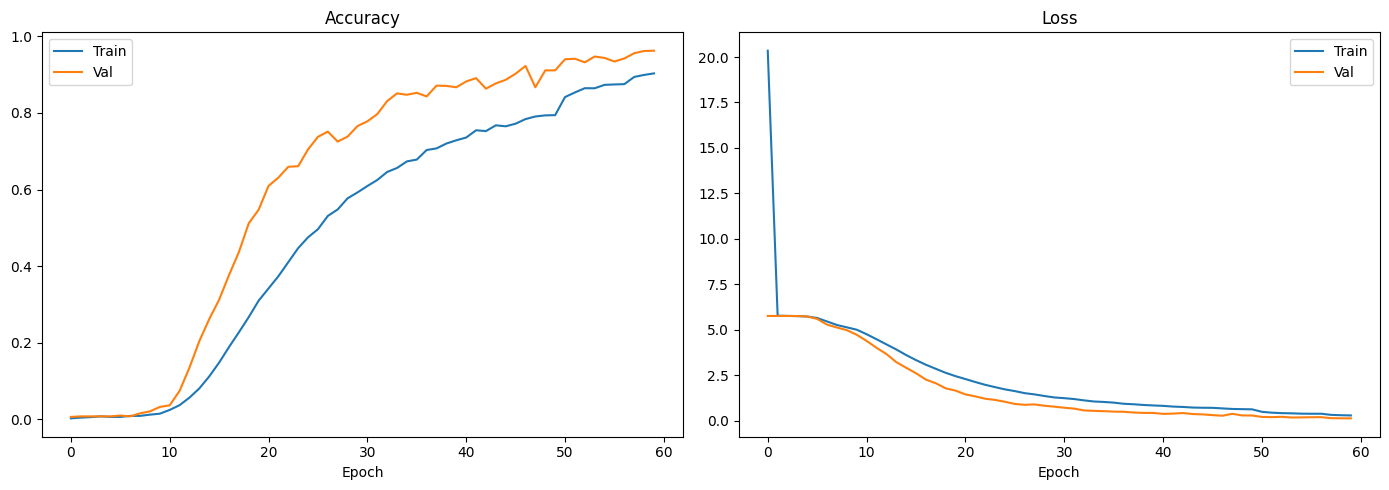

In [ ]:
#3 Save label encoder
np.save("/content/drive/MyDrive/karsl_checkpoints/le_48_clean.npy", le.classes_)

# ── Split train into train/val ─────────────────────────────────────────────────
y_train_cat = to_categorical(y_train, num_classes=num_classes)

X_train_fit, X_val_fit, y_train_fit, y_val_fit = train_test_split(
    X_train, y_train_cat,
    test_size=0.1,
    random_state=42,
    stratify=y_train
)

print(f"\nTrain fit: {X_train_fit.shape}")
print(f"Val fit:   {X_val_fit.shape}")
print(f"num_classes: {num_classes}")

# ── Model ──────────────────────────────────────────────────────────────────────
tf.keras.backend.clear_session()

input_layer = Input(shape=(48, 225))

x = TCN(
    nb_filters=128,
    kernel_size=3,
    nb_stacks=2,
    dilations=[1, 2, 4, 8, 16],
    padding='causal',
    use_skip_connections=True,
    dropout_rate=0.3,
    return_sequences=True
)(input_layer)

x = TCN(
    nb_filters=128,
    kernel_size=3,
    nb_stacks=1,
    dilations=[1, 2, 4, 8],
    padding='causal',
    use_skip_connections=True,
    dropout_rate=0.3,
    return_sequences=False
)(x)

x = Dense(256, activation="relu")(x)
x = Dropout(0.4)(x)

output_layer = Dense(num_classes, activation="softmax")(x)

model = Model(inputs=input_layer, outputs=output_layer)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

# ── Callbacks ──────────────────────────────────────────────────────────────────
checkpoint_cb = tf.keras.callbacks.ModelCheckpoint(
    "/content/drive/MyDrive/karsl_checkpoints/tcn_48_clean.keras",
    save_best_only=True,
    monitor="val_accuracy",
    mode="max"
)

early_stop = tf.keras.callbacks.EarlyStopping(
    patience=7,
    restore_best_weights=True,
    monitor="val_accuracy"
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

# ── Train ──────────────────────────────────────────────────────────────────────
history = model.fit(
    X_train_fit, y_train_fit,
    validation_data=(X_val_fit, y_val_fit),
    epochs=60,
    batch_size=64,
    callbacks=[checkpoint_cb, early_stop, reduce_lr]
)

# ── Evaluate on signer03 combined test ────────────────────────────────────────
y_test_cat = to_categorical(y_test_full, num_classes=num_classes)
loss, acc  = model.evaluate(X_test_full, y_test_cat, batch_size=64, verbose=1)
print(f"\nSigner03 Test Accuracy: {acc*100:.2f}%")

y_pred     = model.predict(X_test_full, batch_size=64, verbose=1)
y_pred_cls = np.argmax(y_pred,    axis=1)
y_true_cls = np.argmax(y_test_cat, axis=1)

top1 = np.mean(y_pred_cls == y_true_cls)
top5 = np.mean([y_true_cls[i] in np.argsort(y_pred[i])[-5:] for i in range(len(y_true_cls))])
print(f"Top-1: {top1*100:.2f}%")
print(f"Top-5: {top5*100:.2f}%")

# ── Plot ───────────────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(history.history["accuracy"],     label="Train")
axes[0].plot(history.history["val_accuracy"], label="Val")
axes[0].set_title("Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(history.history["loss"],     label="Train")
axes[1].plot(history.history["val_loss"], label="Val")
axes[1].set_title("Loss")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.tight_layout()
plt.savefig("/content/drive/MyDrive/karsl_checkpoints/tcn_48_clean_history.png")
plt.show()

In [ ]:
import tensorflow as tf
import numpy as np
from tcn import TCN

# ── Load saved model ───────────────────────────────────────────────────────────
model = tf.keras.models.load_model(
    "/content/drive/MyDrive/karsl_checkpoints/tcn_48_clean.keras"
)
print("Model loaded ✓")
print("Input shape:",  model.input_shape)
print("Output shape:", model.output_shape)

# ── Convert to TFLite ──────────────────────────────────────────────────────────
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_model = converter.convert()

tflite_path = "/content/drive/MyDrive/karsl_checkpoints/tcn_48_clean_final.tflite"
with open(tflite_path, "wb") as f:
    f.write(tflite_model)

size_mb = len(tflite_model) / (1024 * 1024)
print(f"TFLite saved ✓ ({size_mb:.2f} MB)")

Model loaded ✓
Input shape: (None, 48, 225)
Output shape: (None, 317)
Saved artifact at '/tmp/tmpwab4cpl4'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 48, 225), dtype=tf.float32, name='input_layer')
Output Type:
  TensorSpec(shape=(None, 317), dtype=tf.float32, name=None)
Captures:
  135465339619088: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135465339620240: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135465339620048: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135465339619280: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135465339620624: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135465339624272: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135465339620816: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135465339623888: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135465339623504: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135465339624656: 

NameError: name 'le' is not defined

In [ ]:
from sklearn.preprocessing import LabelEncoder
import numpy as np

le_classes = np.load("/content/drive/MyDrive/karsl_checkpoints/le_48_clean.npy")
le = LabelEncoder()
le.classes_ = le_classes  # assign classes first

np.save("/content/drive/MyDrive/karsl_checkpoints/le_48_clean_final.npy", le.classes_)
print("Label encoder saved ✓")
print("Num classes:", len(le.classes_))

Label encoder saved ✓
Num classes: 317


In [ ]:
le_si = np.load("/content/drive/MyDrive/si_label_encoder_clean.npy")
print("Old si le classes:", len(le_si))

Old si le classes: 317


In [ ]:
import pickle
import os

base_path = "/content/drive/MyDrive/karsl_work"

# ── Signer-independent train: signer01 + signer02 (train split only) ───────────
video_list_train = []
for signer in ["01", "02"]:
    for _, row in karsl_df.iterrows():
        word_folder = row["WordFolder"]
        label       = row["ClassIndex"]
        pose_dir = os.path.join(base_path, signer, "train", word_folder, "pose_keypoints")
        lh_dir   = os.path.join(base_path, signer, "train", word_folder, "lh_keypoints")
        rh_dir   = os.path.join(base_path, signer, "train", word_folder, "rh_keypoints")
        if not os.path.exists(pose_dir):
            continue
        for video in sorted(os.listdir(pose_dir)):
            pose_path = os.path.join(pose_dir, video)
            lh_path   = os.path.join(lh_dir,   video)
            rh_path   = os.path.join(rh_dir,   video)
            if os.path.exists(pose_path) and os.path.exists(lh_path) and os.path.exists(rh_path):
                video_list_train.append((pose_path, lh_path, rh_path, int(label)))

with open("/content/drive/MyDrive/video_list_si_train.pkl", "wb") as f:
    pickle.dump(video_list_train, f)
print("Train list:", len(video_list_train))
print("Unique classes:", len(set(v[3] for v in video_list_train)))

# ── Signer-independent val: signer03 train split ───────────────────────────────
video_list_val = []
for _, row in karsl_df.iterrows():
    word_folder = row["WordFolder"]
    label       = row["ClassIndex"]
    pose_dir = os.path.join(base_path, "03", "train", word_folder, "pose_keypoints")
    lh_dir   = os.path.join(base_path, "03", "train", word_folder, "lh_keypoints")
    rh_dir   = os.path.join(base_path, "03", "train", word_folder, "rh_keypoints")
    if not os.path.exists(pose_dir):
        continue
    for video in sorted(os.listdir(pose_dir)):
        pose_path = os.path.join(pose_dir, video)
        lh_path   = os.path.join(lh_dir,   video)
        rh_path   = os.path.join(rh_dir,   video)
        if os.path.exists(pose_path) and os.path.exists(lh_path) and os.path.exists(rh_path):
            video_list_val.append((pose_path, lh_path, rh_path, int(label)))

with open("/content/drive/MyDrive/video_list_si_val.pkl", "wb") as f:
    pickle.dump(video_list_val, f)
print("Val list:", len(video_list_val))
print("Unique classes:", len(set(v[3] for v in video_list_val)))

# ── Signer-independent test: signer03 test split ──────────────────────────────
video_list_test = []
for _, row in karsl_df.iterrows():
    word_folder = row["WordFolder"]
    label       = row["ClassIndex"]
    pose_dir = os.path.join(base_path, "03", "test", word_folder, "pose_keypoints")
    lh_dir   = os.path.join(base_path, "03", "test", word_folder, "lh_keypoints")
    rh_dir   = os.path.join(base_path, "03", "test", word_folder, "rh_keypoints")
    if not os.path.exists(pose_dir):
        continue
    for video in sorted(os.listdir(pose_dir)):
        pose_path = os.path.join(pose_dir, video)
        lh_path   = os.path.join(lh_dir,   video)
        rh_path   = os.path.join(rh_dir,   video)
        if os.path.exists(pose_path) and os.path.exists(lh_path) and os.path.exists(rh_path):
            video_list_test.append((pose_path, lh_path, rh_path, int(label)))

with open("/content/drive/MyDrive/video_list_si_test.pkl", "wb") as f:
    pickle.dump(video_list_test, f)
print("Test list:", len(video_list_test))
print("Unique classes:", len(set(v[3] for v in video_list_test)))

Train list: 38859
Unique classes: 502
Val list: 21080
Unique classes: 502
Test list: 4006
Unique classes: 502


In [ ]:
import numpy as np
import pickle
import os
from tqdm.notebook import tqdm

MAX_FRAMES  = 70
feature_dim = 225

def build_dataset(video_list_path, X_save_path, y_save_path, checkpoint_path):
    # Load video list
    with open(video_list_path, "rb") as f:
        video_list = pickle.load(f)
    print(f"Video list loaded: {len(video_list)} samples")
    print(f"Unique classes: {len(set(v[3] for v in video_list))}")

    total = len(video_list)

    # ── Resume or start fresh ──────────────────────────────────────────────────
    if os.path.exists(checkpoint_path):
        start_index = int(np.load(checkpoint_path))
        if start_index >= total:
            print("Already complete, loading saved files...")
            return np.load(X_save_path), np.load(y_save_path)
        print(f"Resuming from index {start_index}/{total}")
        X_all = np.load(X_save_path)
        y_all = np.load(y_save_path)
    else:
        start_index = 0
        print("Starting fresh")
        X_all = np.zeros((total, MAX_FRAMES, feature_dim), dtype="float32")
        y_all = np.zeros((total,), dtype="int32")

    pbar = tqdm(total=total, initial=start_index, desc=f"Building {os.path.basename(X_save_path)}")

    for index in range(start_index, total):
        pose_path, lh_path, rh_path, label = video_list[index]

        pose = np.load(pose_path)
        lh   = np.load(lh_path)
        rh   = np.load(rh_path)

        if pose.size == 0 or lh.size == 0 or rh.size == 0:
            pbar.update(1)
            continue

        combined = np.concatenate([
            pose.reshape(pose.shape[0], -1),
            lh.reshape(lh.shape[0], -1),
            rh.reshape(rh.shape[0], -1)
        ], axis=1)

        if combined.shape[0] > MAX_FRAMES:
            idx      = np.linspace(0, combined.shape[0]-1, MAX_FRAMES, dtype=int)
            combined = combined[idx]
        else:
            pad      = np.zeros((MAX_FRAMES - combined.shape[0], combined.shape[1]))
            combined = np.vstack([combined, pad])

        X_all[index] = combined.astype("float32")
        y_all[index] = label
        pbar.update(1)

        # Save checkpoint every 2000 samples
        if index % 2000 == 0:
            np.save(X_save_path,    X_all)
            np.save(y_save_path,    y_all)
            np.save(checkpoint_path, index)

    pbar.close()

    # Final save
    np.save(X_save_path,    X_all)
    np.save(y_save_path,    y_all)
    np.save(checkpoint_path, total)  # mark complete

    # Verify
    print(f"Unique classes: {len(np.unique(y_all))}")
    print(f"Max class:      {y_all.max()}")
    print(f"Saved: {X_save_path}")
    print()

    return X_all, y_all

# ── Build all three splits ─────────────────────────────────────────────────────
X_train, y_train = build_dataset(
    "/content/drive/MyDrive/video_list_si_train.pkl",
    "/content/drive/MyDrive/X_si_train_1.npy",
    "/content/drive/MyDrive/y_si_train_1.npy",
    "/content/drive/MyDrive/ckpt_si_train.npy"
)

X_val, y_val = build_dataset(
    "/content/drive/MyDrive/video_list_si_val.pkl",
    "/content/drive/MyDrive/X_si_val.npy",
    "/content/drive/MyDrive/y_si_val.npy",
    "/content/drive/MyDrive/ckpt_si_val.npy"
)

X_test, y_test = build_dataset(
    "/content/drive/MyDrive/video_list_si_test.pkl",
    "/content/drive/MyDrive/X_si_test.npy",
    "/content/drive/MyDrive/y_si_test.npy",
    "/content/drive/MyDrive/ckpt_si_test.npy"
)

# ── Final summary ──────────────────────────────────────────────────────────────
print("Final summary:")
print(f"Train: {X_train.shape} | Classes: {len(np.unique(y_train))}")
print(f"Val:   {X_val.shape}   | Classes: {len(np.unique(y_val))}")
print(f"Test:  {X_test.shape}  | Classes: {len(np.unique(y_test))}")

Video list loaded: 38859 samples
Unique classes: 502
Resuming from index 20000/38859


Building X_si_train_1.npy:  51%|#####1    | 20000/38859 [00:00<?, ?it/s]

Unique classes: 417
Max class:      416
Saved: /content/drive/MyDrive/X_si_train_1.npy

Video list loaded: 21080 samples
Unique classes: 502
Starting fresh


Building X_si_val.npy:   0%|          | 0/21080 [00:00<?, ?it/s]

Unique classes: 178
Max class:      177
Saved: /content/drive/MyDrive/X_si_val.npy

Video list loaded: 4006 samples
Unique classes: 502
Starting fresh


Building X_si_test.npy:   0%|          | 0/4006 [00:00<?, ?it/s]

Unique classes: 317
Max class:      316
Saved: /content/drive/MyDrive/X_si_test.npy

Final summary:
Train: (38859, 70, 225) | Classes: 417
Val:   (21080, 70, 225)   | Classes: 178
Test:  (4006, 70, 225)  | Classes: 317


In [ ]:
import numpy as np
from sklearn.preprocessing import LabelEncoder

y_train = np.load("/content/drive/MyDrive/y_si_train_1.npy")
y_test  = np.load("/content/drive/MyDrive/y_si_test.npy")
X_train = np.load("/content/drive/MyDrive/X_si_train_1.npy")
X_test  = np.load("/content/drive/MyDrive/X_si_test.npy")

# Common classes between train and test only
train_classes = set(np.unique(y_train).tolist())
test_classes  = set(np.unique(y_test).tolist())
common        = sorted(train_classes & test_classes)
print(f"Common classes: {len(common)}")

# Filter and remap
le = LabelEncoder()
le.fit(common)

# Train
mask_train = np.isin(y_train, common)
X_train_f  = X_train[mask_train]
y_train_f  = le.transform(y_train[mask_train])

# Test
mask_test  = np.isin(y_test, common)
X_test_f   = X_test[mask_test]
y_test_f   = le.transform(y_test[mask_test])

print(f"Train: {X_train_f.shape} | Classes: {len(np.unique(y_train_f))}")
print(f"Test:  {X_test_f.shape}  | Classes: {len(np.unique(y_test_f))}")

# Save
np.save("/content/drive/MyDrive/X_si_train_f.npy", X_train_f)
np.save("/content/drive/MyDrive/y_si_train_f.npy", y_train_f)
np.save("/content/drive/MyDrive/X_si_test_f.npy",  X_test_f)
np.save("/content/drive/MyDrive/y_si_test_f.npy",  y_test_f)
np.save("/content/drive/MyDrive/si_label_encoder.npy", le.classes_)
print("Saved ✓")

Common classes: 317
Train: (34740, 70, 225) | Classes: 317
Test:  (4006, 70, 225)  | Classes: 317
Saved ✓


In [ ]:
!pip install keras-tcn

X_test shape: (4006, 70, 225)
y_test shape: (4006,)
Unique classes: 317
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 61ms/step - accuracy: 0.4773 - loss: 2.9927
Test Loss:     2.9927
Test Accuracy: 0.4773 (47.73%)
63/63 ━━━━━━━━━━━━━━━━━━━━ 6s 49ms/step
Top-1 Accuracy: 47.73%
Top-5 Accuracy: 62.96%

Classification Report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      1478
           1       0.00      0.00      0.00         8
           2       0.00      0.00      0.00         8
           3       0.00      0.00      0.00         8
           4       0.00      0.00      0.00         8
           5       0.00      0.00      0.00         8
           6       0.00      0.00      0.00         8
           7       0.19      0.38      0.25         8
           8       0.00      0.00      0.00         8
           9       0.00      0.00      0.00         8
          10       0.00      0.00      0.00         8
          11       0.00      0.00      0.0

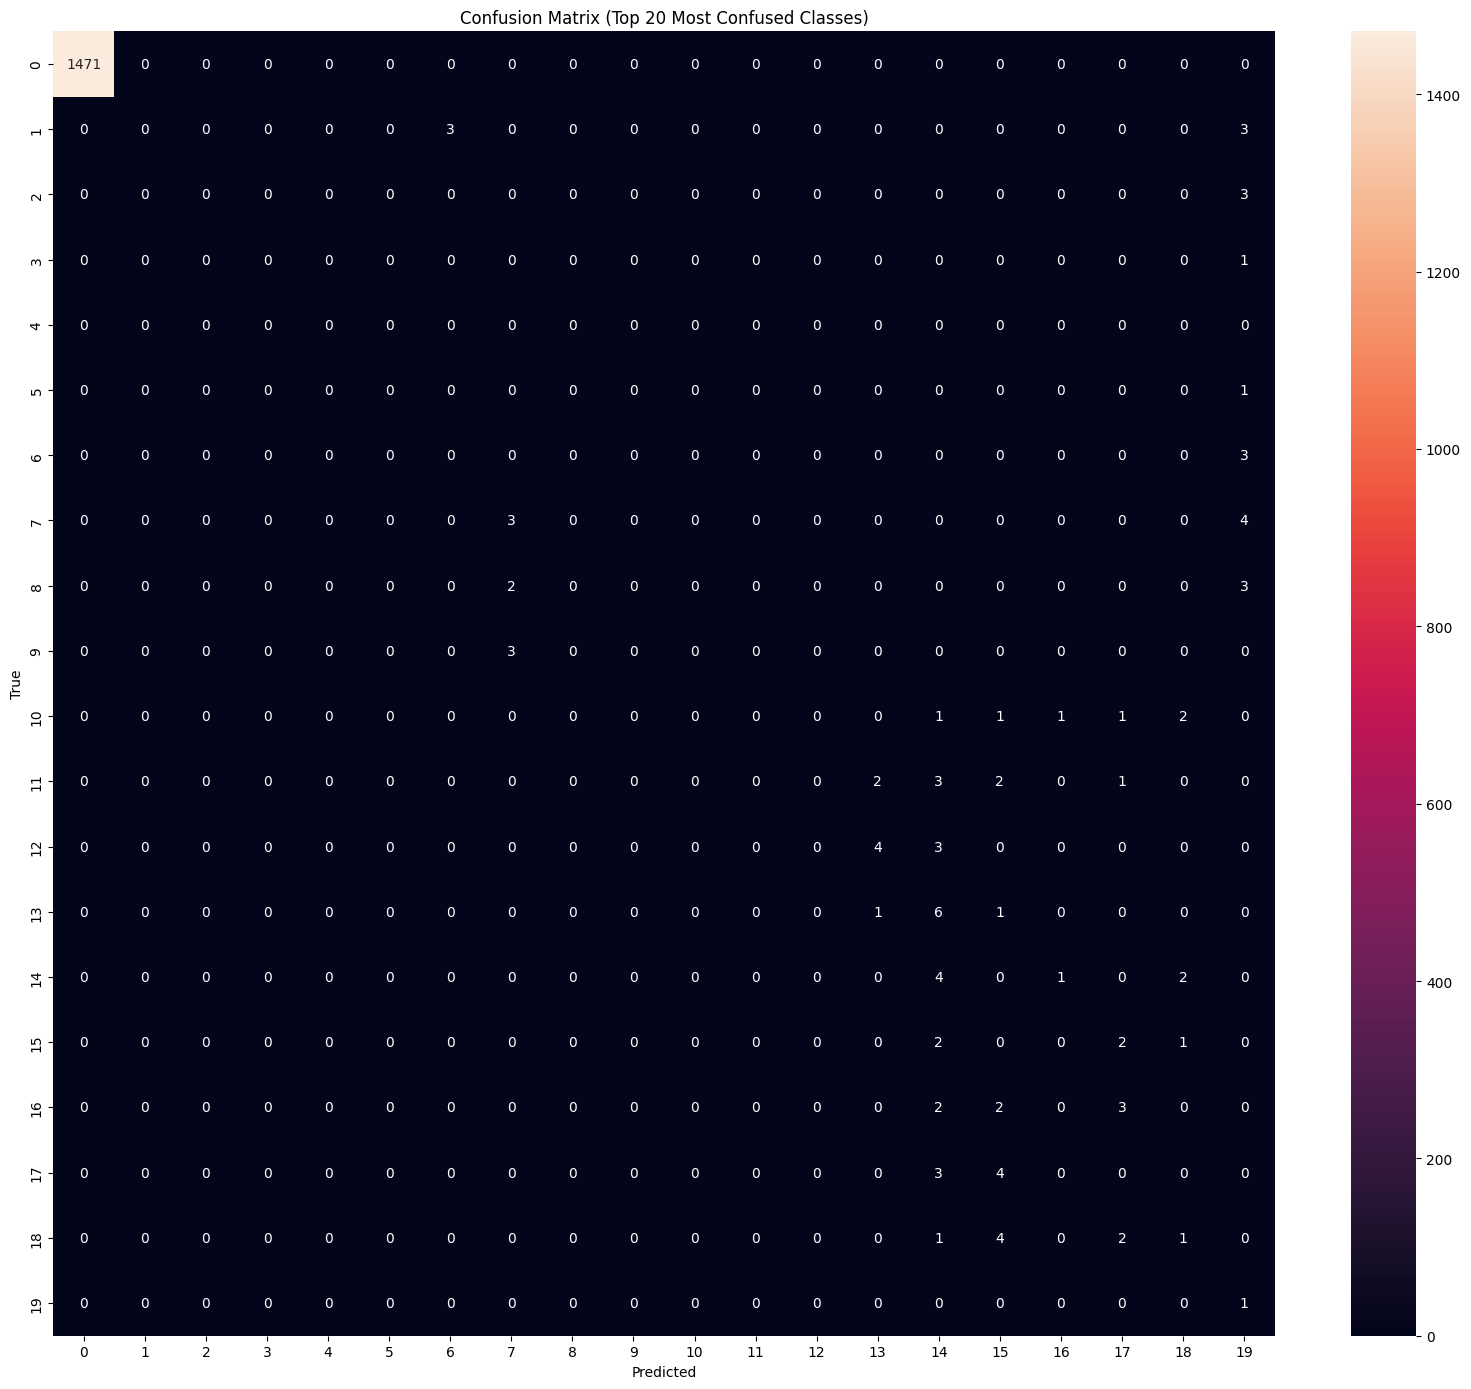

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical
import seaborn as sns

MAX_FRAMES  = 70
feature_dim = 225
num_classes = 317

# ── Load test data ─────────────────────────────────────────────────────────────
X_test = np.load("/content/drive/MyDrive/X_si_test_f.npy")
y_test = np.load("/content/drive/MyDrive/y_si_test_f.npy")

print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)
print("Unique classes:", len(np.unique(y_test)))

# ── One-hot encode ─────────────────────────────────────────────────────────────
y_test_cat = to_categorical(y_test, num_classes=num_classes)

# ── Evaluate ───────────────────────────────────────────────────────────────────
loss, accuracy = model.evaluate(X_test, y_test_cat, batch_size=64, verbose=1)
print(f"Test Loss:     {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")

# ── Predictions ────────────────────────────────────────────────────────────────
y_pred     = model.predict(X_test, batch_size=64, verbose=1)
y_pred_cls = np.argmax(y_pred,     axis=1)
y_true_cls = np.argmax(y_test_cat, axis=1)

# ── Top-1 and Top-5 ───────────────────────────────────────────────────────────
top1 = np.mean(y_pred_cls == y_true_cls)
top5 = np.mean([y_true_cls[i] in np.argsort(y_pred[i])[-5:] for i in range(len(y_true_cls))])
print(f"Top-1 Accuracy: {top1*100:.2f}%")
print(f"Top-5 Accuracy: {top5*100:.2f}%")

# ── Classification report ──────────────────────────────────────────────────────
print("\nClassification Report:")
print(classification_report(y_true_cls, y_pred_cls, zero_division=0))

# ── Confusion matrix (top 20 most confused) ────────────────────────────────────
errors        = np.where(y_pred_cls != y_true_cls)[0]
error_true    = y_true_cls[errors]
most_confused = np.unique(error_true)[:20]

cm = confusion_matrix(
    y_true_cls[np.isin(y_true_cls, most_confused)],
    y_pred_cls[np.isin(y_true_cls, most_confused)],
    labels=most_confused
)

# Load label encoder to show original class indices
le_classes = np.load("/content/drive/MyDrive/si_label_encoder.npy")
labels_orig = [le_classes[i] for i in most_confused]

plt.figure(figsize=(16, 14))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=labels_orig, yticklabels=labels_orig)
plt.title("Confusion Matrix (Top 20 Most Confused Classes)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/karsl_checkpoints/confusion_matrix_si.png")
plt.show()

In [ ]:
le_classes = np.load("/content/drive/MyDrive/si_label_encoder.npy")
print("Class 0 original label:", le_classes[0])

# Check class distribution in test
from collections import Counter
counts = Counter(y_test.tolist())
print("\nTop 10 most frequent classes:")
for cls, cnt in sorted(counts.items(), key=lambda x: -x[1])[:10]:
    print(f"  Class {cls} (original {le_classes[cls]}): {cnt} samples")

# Check train distribution
counts_train = Counter(y_train.tolist())
print("\nClass 0 in train:", counts_train[0])
print("Average other classes in train:",
      sum(v for k,v in counts_train.items() if k != 0) // (len(counts_train)-1))

Class 0 original label: 0

Top 10 most frequent classes:
  Class 0 (original 0): 1478 samples
  Class 35 (original 35): 10 samples
  Class 1 (original 1): 8 samples
  Class 2 (original 2): 8 samples
  Class 3 (original 3): 8 samples
  Class 4 (original 4): 8 samples
  Class 5 (original 5): 8 samples
  Class 6 (original 6): 8 samples
  Class 7 (original 7): 8 samples
  Class 8 (original 8): 8 samples

Class 0 in train: 17902
Average other classes in train: 50


In [ ]:
import pickle

with open("/content/drive/MyDrive/video_list_si_train.pkl", "rb") as f:
    video_list_train = pickle.load(f)

# Check class 0 vs others
class0_videos = sum(1 for _, _, _, l in video_list_train if l == 0)
class1_videos = sum(1 for _, _, _, l in video_list_train if l == 1)
print(f"Class 0 videos: {class0_videos}")
print(f"Class 1 videos: {class1_videos}")

# Check what word class 0 is
print("Class 0 word:", karsl_df[karsl_df["ClassIndex"] == 0][["Sign-Arabic", "Sign-English"]])

# Full distribution
from collections import Counter
label_counts = Counter(l for _, _, _, l in video_list_train)
print(f"\nTotal classes: {len(label_counts)}")
print(f"Min samples: {min(label_counts.values())}")
print(f"Max samples: {max(label_counts.values())}")
print(f"Mean samples: {sum(label_counts.values())/len(label_counts):.1f}")
print(f"\nTop 5 most frequent:")
for cls, cnt in sorted(label_counts.items(), key=lambda x: -x[1])[:5]:
    print(f"  Class {cls}: {cnt} videos")

Class 0 videos: 85
Class 1 videos: 84
Class 0 word:   Sign-Arabic Sign-English
0           0            0

Total classes: 502
Min samples: 40
Max samples: 126
Mean samples: 77.4

Top 5 most frequent:
  Class 26: 126 videos
  Class 4: 110 videos
  Class 239: 91 videos
  Class 374: 91 videos
  Class 103: 90 videos


In [ ]:
y_test_raw = np.load("/content/drive/MyDrive/y_si_test_f.npy")
from collections import Counter
counts = Counter(y_test_raw.tolist())
print(f"Total samples: {len(y_test_raw)}")
print(f"Total classes: {len(counts)}")
print(f"\nTop 5 most frequent:")
for cls, cnt in sorted(counts.items(), key=lambda x: -x[1])[:5]:
    print(f"  Class {cls}: {cnt} samples")

# Check video list for test
with open("/content/drive/MyDrive/video_list_si_test.pkl", "rb") as f:
    video_list_test = pickle.load(f)

test_counts = Counter(l for _, _, _, l in video_list_test)
print(f"\nIn video_list_test:")
print(f"Top 5: {sorted(test_counts.items(), key=lambda x: -x[1])[:5]}")
print(f"Class 0 in test list: {test_counts.get(0, 0)}")

Total samples: 4006
Total classes: 317

Top 5 most frequent:
  Class 0: 1478 samples
  Class 35: 10 samples
  Class 1: 8 samples
  Class 2: 8 samples
  Class 3: 8 samples

In video_list_test:
Top 5: [(35, 10), (0, 8), (1, 8), (2, 8), (3, 8)]
Class 0 in test list: 8


In [ ]:
# Find samples that were actually written (non-zero X)
X_test_raw = np.load("/content/drive/MyDrive/X_si_test_f.npy")
y_test_raw = np.load("/content/drive/MyDrive/y_si_test_f.npy")

# Valid samples have non-zero keypoint data
valid_mask  = X_test_raw.sum(axis=(1, 2)) != 0
X_test_clean = X_test_raw[valid_mask]
y_test_clean = y_test_raw[valid_mask]

print(f"Before: {len(y_test_raw)} samples")
print(f"After:  {len(y_test_clean)} samples")
print(f"Removed: {len(y_test_raw) - len(y_test_clean)} empty samples")

from collections import Counter
counts = Counter(y_test_clean.tolist())
print(f"Total classes: {len(counts)}")
print(f"Top 5: {sorted(counts.items(), key=lambda x: -x[1])[:5]}")

Before: 4006 samples
After:  2536 samples
Removed: 1470 empty samples
Total classes: 317
Top 5: [(35, 10), (0, 8), (1, 8), (2, 8), (3, 8)]


In [ ]:
X_train_raw = np.load("/content/drive/MyDrive/X_si_train_f.npy")
y_train_raw = np.load("/content/drive/MyDrive/y_si_train_f.npy")

valid_mask_train  = X_train_raw.sum(axis=(1, 2)) != 0
X_train_clean = X_train_raw[valid_mask_train]
y_train_clean = y_train_raw[valid_mask_train]

print(f"Train before: {len(y_train_raw)} | after: {len(y_train_clean)}")
print(f"Classes: {len(np.unique(y_train_clean))}")

Train before: 34740 | after: 15822
Classes: 317


In [ ]:
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.utils import to_categorical
from tcn import TCN
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout

# ── Load and clean data ────────────────────────────────────────────────────────
X_train_raw = np.load("/content/drive/MyDrive/X_si_train_f.npy")
y_train_raw = np.load("/content/drive/MyDrive/y_si_train_f.npy")
X_test_raw  = np.load("/content/drive/MyDrive/X_si_test_f.npy")
y_test_raw  = np.load("/content/drive/MyDrive/y_si_test_f.npy")

# Remove zero-padded empty samples
valid_train  = X_train_raw.sum(axis=(1, 2)) != 0
valid_test   = X_test_raw.sum(axis=(1, 2))  != 0

X_train = X_train_raw[valid_train]
y_train = y_train_raw[valid_train]
X_test  = X_test_raw[valid_test]
y_test  = y_test_raw[valid_test]

print(f"Train: {X_train.shape} | Classes: {len(np.unique(y_train))}")
print(f"Test:  {X_test.shape}  | Classes: {len(np.unique(y_test))}")

# ── Keep only common classes ───────────────────────────────────────────────────
from sklearn.preprocessing import LabelEncoder

train_classes  = set(np.unique(y_train).tolist())
test_classes   = set(np.unique(y_test).tolist())
common_classes = sorted(train_classes & test_classes)
num_classes    = len(common_classes)
print(f"Common classes: {num_classes}")

le = LabelEncoder()
le.fit(common_classes)

mask_train  = np.isin(y_train, common_classes)
mask_test   = np.isin(y_test,  common_classes)
X_train     = X_train[mask_train]
y_train     = le.transform(y_train[mask_train])
X_test      = X_test[mask_test]
y_test      = le.transform(y_test[mask_test])

print(f"Train after filter: {X_train.shape} | Classes: {len(np.unique(y_train))}")
print(f"Test after filter:  {X_test.shape}  | Classes: {len(np.unique(y_test))}")

# Save label encoder
np.save("/content/drive/MyDrive/si_label_encoder_clean.npy", le.classes_)

# ── One-hot encode ─────────────────────────────────────────────────────────────
y_train_cat = to_categorical(y_train, num_classes=num_classes)

# ── Train/val split ────────────────────────────────────────────────────────────
X_train_fit, X_val_fit, y_train_fit, y_val_fit = train_test_split(
    X_train, y_train_cat,
    test_size=0.1,
    random_state=42,
    stratify=y_train
)

print(f"Train fit: {X_train_fit.shape}")
print(f"Val fit:   {X_val_fit.shape}")

# ── Class weights ──────────────────────────────────────────────────────────────
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weight_dict = dict(zip(np.unique(y_train), class_weights))

# ── Model ──────────────────────────────────────────────────────────────────────
input_layer = Input(shape=(70, 225))

x = TCN(
    nb_filters=128,
    kernel_size=3,
    nb_stacks=2,
    dilations=[1, 2, 4, 8, 16],
    padding='causal',
    use_skip_connections=True,
    dropout_rate=0.3,
    return_sequences=True
)(input_layer)

x = TCN(
    nb_filters=128,
    kernel_size=3,
    nb_stacks=1,
    dilations=[1, 2, 4, 8],
    padding='causal',
    use_skip_connections=True,
    dropout_rate=0.3,
    return_sequences=False
)(x)

x = Dense(256, activation="relu")(x)
x = Dropout(0.4)(x)

output_layer = Dense(num_classes, activation="softmax")(x)

model = Model(inputs=input_layer, outputs=output_layer)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

# ── Callbacks ──────────────────────────────────────────────────────────────────
checkpoint_cb = tf.keras.callbacks.ModelCheckpoint(
    "/content/drive/MyDrive/karsl_checkpoints/tcn_si_clean_1.keras",
    save_best_only=True,
    monitor="val_accuracy",
    mode="max"
)

early_stop = tf.keras.callbacks.EarlyStopping(
    patience=5,
    restore_best_weights=True,
    monitor="val_accuracy"
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

# ── Train ──────────────────────────────────────────────────────────────────────
history = model.fit(
    X_train_fit, y_train_fit,
    validation_data=(X_val_fit, y_val_fit),
    epochs=50,
    batch_size=64,
    class_weight=class_weight_dict,
    callbacks=[checkpoint_cb, early_stop, reduce_lr]
)

# ── Plot ───────────────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history["accuracy"],     label="Train")
axes[0].plot(history.history["val_accuracy"], label="Val")
axes[0].set_title("Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(history.history["loss"],     label="Train")
axes[1].plot(history.history["val_loss"], label="Val")
axes[1].set_title("Loss")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.tight_layout()
plt.savefig("/content/drive/MyDrive/karsl_checkpoints/tcn_si_clean_history_1.png")
plt.show()

Train: (15822, 70, 225) | Classes: 317
Test:  (2536, 70, 225)  | Classes: 317
Common classes: 317
Train after filter: (15822, 70, 225) | Classes: 317
Test after filter:  (2536, 70, 225)  | Classes: 317
Train fit: (14239, 70, 225)
Val fit:   (1583, 70, 225)


KeyboardInterrupt: 

In [ ]:
print("X_train_fit min/max:", X_train_fit.min(), X_train_fit.max())
print("y_train_fit sample:", y_train_fit[0])
print("Non-zero X samples:", np.sum(X_train_fit.sum(axis=(1,2)) != 0))

X_train_fit min/max: -1.7702448 2.8070047
y_train_fit sample: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0

In [ ]:
# Clear session and rebuild model fresh
import tensorflow as tf
from tcn import TCN
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split

tf.keras.backend.clear_session()

# ── Rebuild model ──────────────────────────────────────────────────────────────
input_layer = Input(shape=(70, 225))

x = TCN(
    nb_filters=128,
    kernel_size=3,
    nb_stacks=2,
    dilations=[1, 2, 4, 8, 16],
    padding='causal',
    use_skip_connections=True,
    dropout_rate=0.3,
    return_sequences=True
)(input_layer)

x = TCN(
    nb_filters=128,
    kernel_size=3,
    nb_stacks=1,
    dilations=[1, 2, 4, 8],
    padding='causal',
    use_skip_connections=True,
    dropout_rate=0.3,
    return_sequences=False
)(x)

x = Dense(256, activation="relu")(x)
x = Dropout(0.4)(x)

output_layer = Dense(num_classes, activation="softmax")(x)

model = Model(inputs=input_layer, outputs=output_layer)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),  # higher LR
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# ── Verify data before training ────────────────────────────────────────────────
print("X_train_fit shape:", X_train_fit.shape)
print("y_train_fit shape:", y_train_fit.shape)
print("num_classes:", num_classes)
print("y sum per sample (should be 1.0):", y_train_fit.sum(axis=1)[:5])

# ── Train ──────────────────────────────────────────────────────────────────────
checkpoint_cb = tf.keras.callbacks.ModelCheckpoint(
    "/content/drive/MyDrive/karsl_checkpoints/tcn_si_clean_2.keras",
    save_best_only=True,
    monitor="val_accuracy",
    mode="max"
)

early_stop = tf.keras.callbacks.EarlyStopping(
    patience=5,
    restore_best_weights=True,
    monitor="val_accuracy"
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

history = model.fit(
    X_train_fit, y_train_fit,
    validation_data=(X_val_fit, y_val_fit),
    epochs=50,
    batch_size=64,
    callbacks=[checkpoint_cb, early_stop, reduce_lr]
)

X_train_fit shape: (14239, 70, 225)
y_train_fit shape: (14239, 317)
num_classes: 317
y sum per sample (should be 1.0): [1. 1. 1. 1. 1.]
Epoch 1/50
223/223 ━━━━━━━━━━━━━━━━━━━━ 312s 1s/step - accuracy: 0.0037 - loss: 30.9124 - val_accuracy: 0.0082 - val_loss: 5.7518 - learning_rate: 0.0010
Epoch 2/50
223/223 ━━━━━━━━━━━━━━━━━━━━ 284s 1s/step - accuracy: 0.0058 - loss: 5.7626 - val_accuracy: 0.0076 - val_loss: 5.7418 - learning_rate: 0.0010
Epoch 3/50
223/223 ━━━━━━━━━━━━━━━━━━━━ 281s 1s/step - accuracy: 0.0070 - loss: 5.7367 - val_accuracy: 0.0069 - val_loss: 5.7103 - learning_rate: 0.0010
Epoch 4/50
223/223 ━━━━━━━━━━━━━━━━━━━━ 324s 1s/step - accuracy: 0.0065 - loss: 5.6014 - val_accuracy: 0.0082 - val_loss: 5.3764 - learning_rate: 0.0010
Epoch 5/50
223/223 ━━━━━━━━━━━━━━━━━━━━ 284s 1s/step - accuracy: 0.0079 - loss: 5.4188 - val_accuracy: 0.0120 - val_loss: 5.2486 - learning_rate: 0.0010
Epoch 6/50
223/223 ━━━━━━━━━━━━━━━━━━━━ 327s 1s/step - accuracy: 0.0094 - loss: 5.2701 - val_accur

In [ ]:
import tensorflow as tf
import numpy as np

# ── Save full model ────────────────────────────────────────────────────────────
model.save("/content/drive/MyDrive/karsl_checkpoints/tcn_si_final.keras")
print("Model saved ✓")

# ── Convert to TFLite ──────────────────────────────────────────────────────────
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_model = converter.convert()

tflite_path = "/content/drive/MyDrive/karsl_checkpoints/tcn_si_final.tflite"
with open(tflite_path, "wb") as f:
    f.write(tflite_model)

size_mb = len(tflite_model) / (1024 * 1024)
print(f"TFLite model saved ✓ ({size_mb:.2f} MB)")

# ── Verify ─────────────────────────────────────────────────────────────────────
interpreter = tf.lite.Interpreter(model_path=tflite_path)
interpreter.allocate_tensors()
input_details  = interpreter.get_input_details()
output_details = interpreter.get_output_details()
print("Input shape:",  input_details[0]['shape'])
print("Output shape:", output_details[0]['shape'])

# Test with one sample
test_input = X_train_fit[0:1].astype("float32")
interpreter.set_tensor(input_details[0]['index'], test_input)
interpreter.invoke()
output = interpreter.get_tensor(output_details[0]['index'])
print("Predicted class:", np.argmax(output))
print("True class:     ", np.argmax(y_train_fit[0]))
print("TFLite verified ✓")

Model saved ✓
Saved artifact at '/tmp/tmp6nt7mf4z'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 70, 225), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 317), dtype=tf.float32, name=None)
Captures:
  138369399118288: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138369406917264: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138360629446032: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138367137408464: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138367137407888: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138367137408272: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138367137407696: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138367137408656: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138367137406352: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138367137408848: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


In [ ]:
# Already saved but save again to be sure
np.save("/content/drive/MyDrive/karsl_checkpoints/si_label_encoder_clean.npy", le.classes_)
print("Label encoder saved ✓")

Label encoder saved ✓


Test samples: (2536, 70, 225)
Test classes: 317
40/40 ━━━━━━━━━━━━━━━━━━━━ 19s 470ms/step - accuracy: 0.3450 - loss: 5.1682

Test Loss:     5.1682
Test Accuracy: 0.3450 (34.50%)
40/40 ━━━━━━━━━━━━━━━━━━━━ 16s 384ms/step
Top-1 Accuracy: 34.50%
Top-5 Accuracy: 63.05%

Classification Report:
              precision    recall  f1-score   support

           0       0.31      0.50      0.38         8
           1       0.50      0.12      0.20         8
           2       1.00      0.25      0.40         8
           3       0.50      0.12      0.20         8
           4       0.14      0.12      0.13         8
           5       0.00      0.00      0.00         8
           6       0.00      0.00      0.00         8
           7       0.00      0.00      0.00         8
           8       0.83      0.62      0.71         8
           9       0.00      0.00      0.00         8
          10       0.67      0.25      0.36         8
          11       0.80      0.50      0.62         8
       

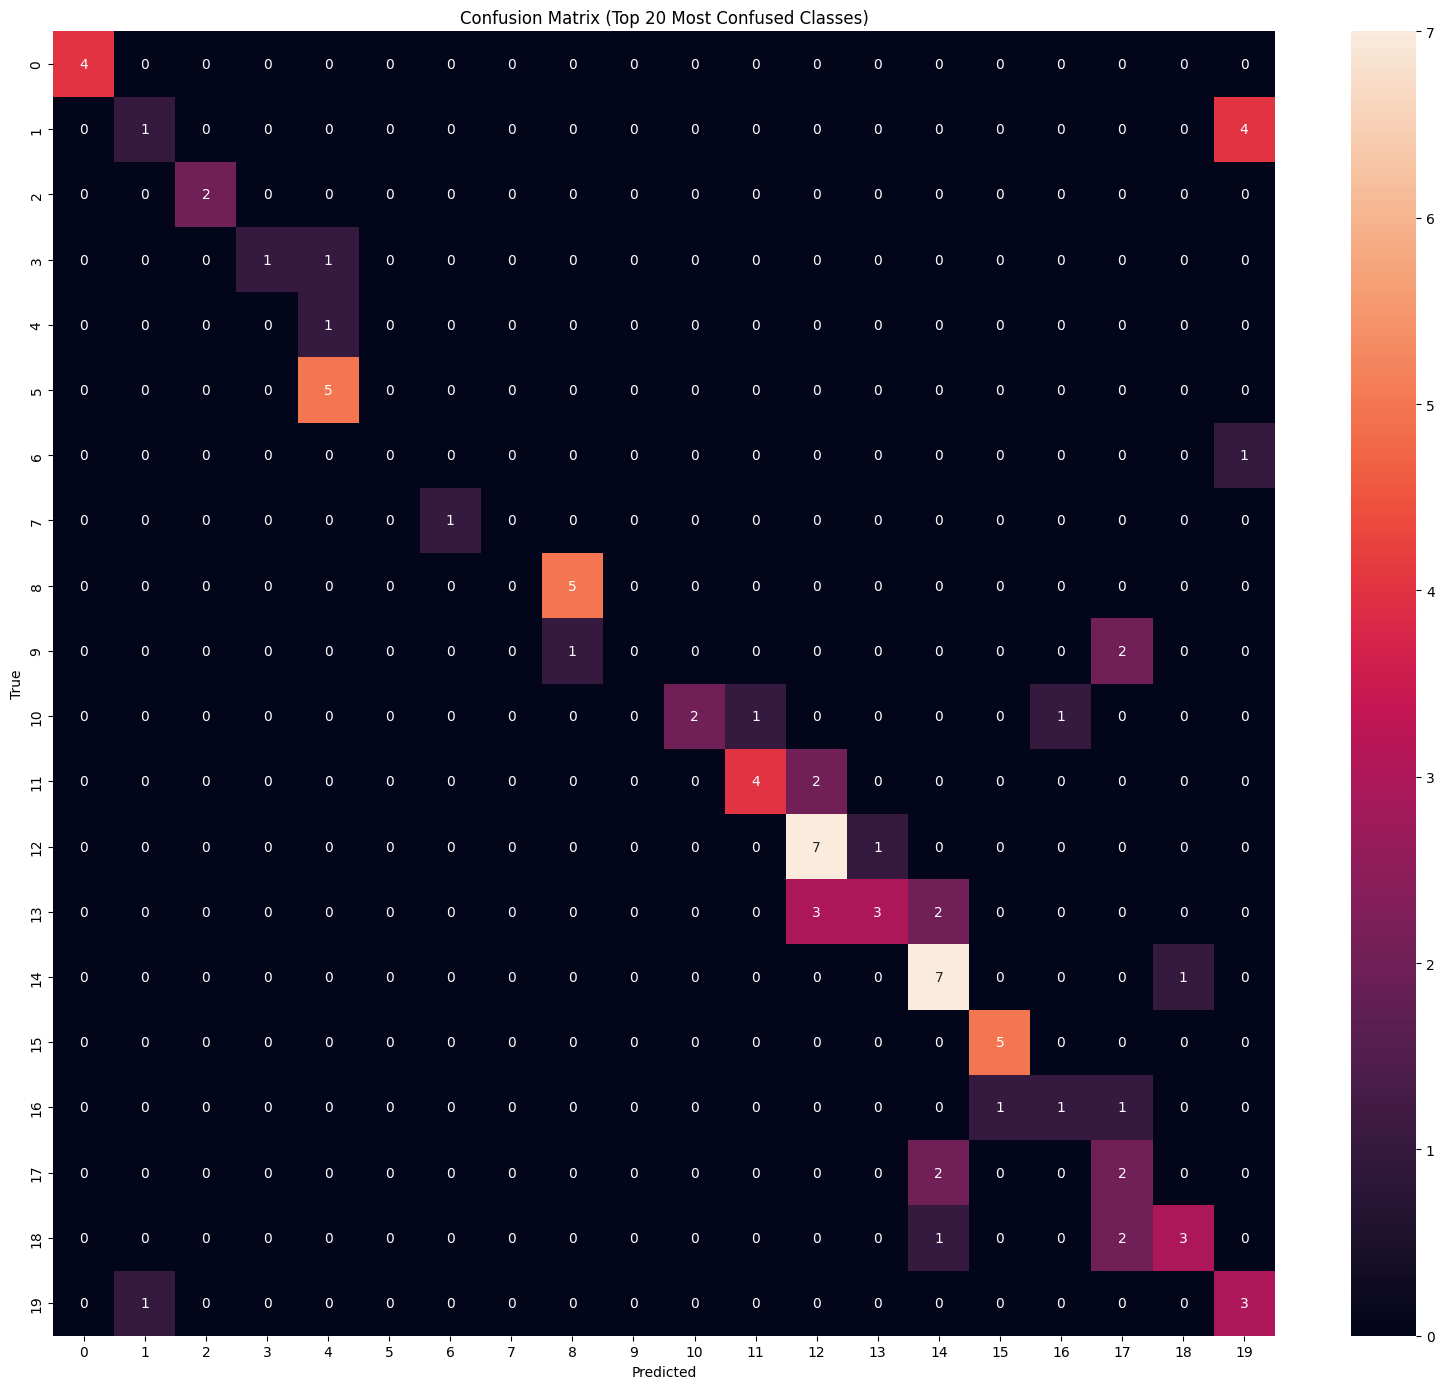

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras.utils import to_categorical
import seaborn as sns

# ── Load and clean test data ───────────────────────────────────────────────────
X_test_raw = np.load("/content/drive/MyDrive/X_si_test_f.npy")
y_test_raw = np.load("/content/drive/MyDrive/y_si_test_f.npy")

# Remove zero-padded empty samples
valid_test   = X_test_raw.sum(axis=(1, 2)) != 0
X_test       = X_test_raw[valid_test]
y_test       = y_test_raw[valid_test]

# Keep only common classes
mask_test    = np.isin(y_test, common_classes)
X_test       = X_test[mask_test]
y_test       = le.transform(y_test[mask_test])

print(f"Test samples: {X_test.shape}")
print(f"Test classes: {len(np.unique(y_test))}")

# ── One-hot encode ─────────────────────────────────────────────────────────────
y_test_cat = to_categorical(y_test, num_classes=num_classes)

# ── Evaluate ───────────────────────────────────────────────────────────────────
loss, accuracy = model.evaluate(X_test, y_test_cat, batch_size=64, verbose=1)
print(f"\nTest Loss:     {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")

# ── Predictions ────────────────────────────────────────────────────────────────
y_pred     = model.predict(X_test, batch_size=64, verbose=1)
y_pred_cls = np.argmax(y_pred,     axis=1)
y_true_cls = np.argmax(y_test_cat, axis=1)

# ── Top-1 and Top-5 ───────────────────────────────────────────────────────────
top1 = np.mean(y_pred_cls == y_true_cls)
top5 = np.mean([y_true_cls[i] in np.argsort(y_pred[i])[-5:] for i in range(len(y_true_cls))])
print(f"Top-1 Accuracy: {top1*100:.2f}%")
print(f"Top-5 Accuracy: {top5*100:.2f}%")

# ── Classification report ──────────────────────────────────────────────────────
print("\nClassification Report:")
print(classification_report(y_true_cls, y_pred_cls, zero_division=0))

# ── Confusion matrix (top 20 most confused) ────────────────────────────────────
errors        = np.where(y_pred_cls != y_true_cls)[0]
error_true    = y_true_cls[errors]
most_confused = np.unique(error_true)[:20]

cm = confusion_matrix(
    y_true_cls[np.isin(y_true_cls, most_confused)],
    y_pred_cls[np.isin(y_true_cls, most_confused)],
    labels=most_confused
)

le_classes   = np.load("/content/drive/MyDrive/karsl_checkpoints/si_label_encoder_clean.npy")
labels_orig  = [le_classes[i] for i in most_confused]

plt.figure(figsize=(16, 14))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=labels_orig, yticklabels=labels_orig)
plt.title("Confusion Matrix (Top 20 Most Confused Classes)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/karsl_checkpoints/confusion_matrix_si_clean.png")
plt.show()